# Lecture 4: Multilayer Perceptrons — Theory and Practice

**Machine Learning Applications in Physics (PHYG004)**
Sogang University, 2026 Spring

---

In this tutorial, we build a complete understanding of **Multilayer Perceptrons (MLPs)** — the workhorse of deep learning. We cover:

1. **From Linear to Nonlinear**: Why we need hidden layers and activation functions
2. **Activation Functions**: ReLU, Sigmoid, Tanh — properties and comparison
3. **Building an MLP from Scratch** in JAX
4. **Numerical Stability & Weight Initialization**: Vanishing/exploding gradients and Xavier init
5. **Generalization**: Underfitting, overfitting, and the bias-variance tradeoff
6. **Dropout**: Regularization by injecting noise
7. **Putting It All Together**: Classification on the Two-Moons dataset

> **Reference**: [Dive into Deep Learning, Chapter 5: Multilayer Perceptrons](https://d2l.ai/chapter_multilayer-perceptrons/index.html)

In [1]:
# Setup — run this cell first
# !pip install -q jax jaxlib optax flax matplotlib

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from functools import partial

# Check device
print(f"JAX backend: {jax.default_backend()}")
print(f"JAX version: {jax.__version__}")

JAX backend: cpu
JAX version: 0.9.1


---
## 1. From Linear Models to Multilayer Perceptrons

*This section follows [d2l.ai §5.1](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html).*

### The Limitation of Linear Models

Recall that a linear model computes:

$$\mathbf{o} = \mathbf{W}\mathbf{x} + \mathbf{b}$$

This can only represent **linear (affine) functions**. Stacking two linear layers gives:

$$\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \underbrace{(\mathbf{W}_2\mathbf{W}_1)}_{\mathbf{W}'}\mathbf{x} + \underbrace{(\mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2)}_{\mathbf{b}'}$$

> **An affine function of an affine function is still an affine function.** No matter how many linear layers we stack, we can never escape linearity. — [d2l.ai §5.1](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html)

### The Solution: Activation Functions

An MLP introduces **nonlinear activation functions** $\sigma(\cdot)$ between layers:

$$\mathbf{h} = \sigma(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) \quad \text{(hidden layer)}$$
$$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2 \quad \text{(output layer)}$$

The activation function breaks the linearity, enabling the network to approximate **any continuous function** ([Universal Approximation Theorem; Cybenko, 1989](https://doi.org/10.1007/BF02551274); [Hornik et al., 1989](https://doi.org/10.1016/0893-6080(89)90020-8)).

In [2]:
# Demonstration: stacking linear layers collapses to a single linear layer
key = jr.PRNGKey(42)
k1, k2 = jr.split(key)

W1 = jr.normal(k1, (4, 3))
W2 = jr.normal(k2, (2, 4))

x = jnp.array([1.0, 2.0, 3.0])

# Two-layer linear: W2 @ (W1 @ x)
out_two_layers = W2 @ (W1 @ x)

# Collapsed single layer: (W2 @ W1) @ x
W_collapsed = W2 @ W1
out_collapsed = W_collapsed @ x

print("Two linear layers:  ", out_two_layers)
print("Collapsed (W2·W1):  ", out_collapsed)
print("Difference:         ", jnp.max(jnp.abs(out_two_layers - out_collapsed)))
print("\n→ They are identical! Stacking linear layers adds no expressiveness.")

Two linear layers:   [ 9.119269  -3.3760552]
Collapsed (W2·W1):   [ 9.119268  -3.3760555]
Difference:          9.536743e-07

→ They are identical! Stacking linear layers adds no expressiveness.


W0319 21:47:17.842146 52837674 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


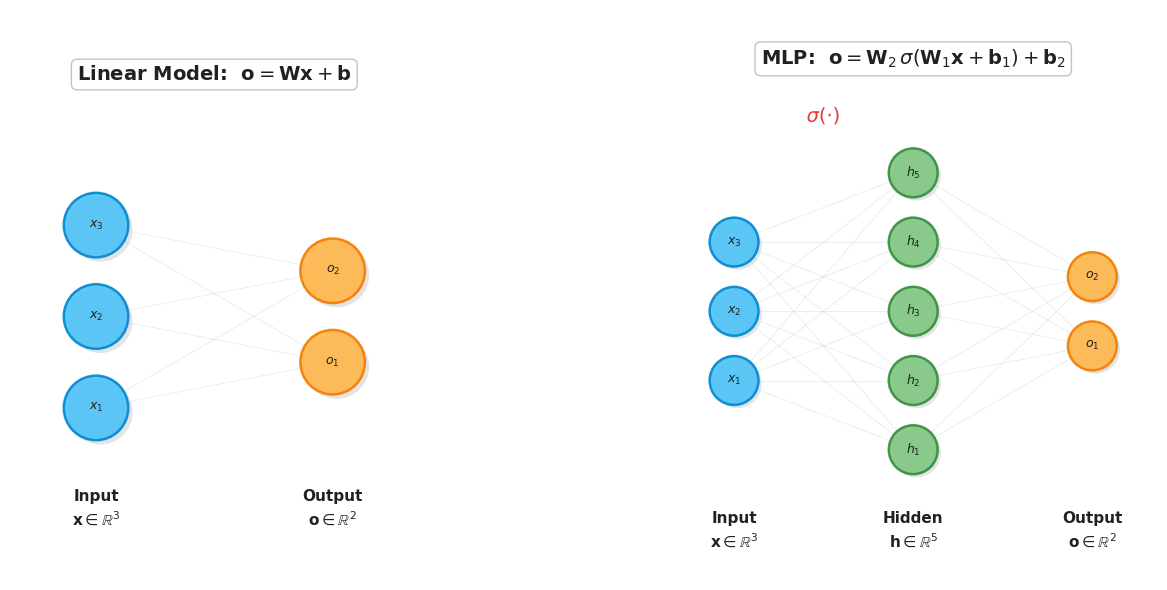

In [3]:
import matplotlib.patheffects as path_effects
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

# ---------- Professional MLP Architecture Diagram ----------

# Color palette
C = {
    'input':  '#4FC3F7',  'input_edge':  '#0288D1',
    'hidden': '#81C784',  'hidden_edge': '#388E3C',
    'output': '#FFB74D',  'output_edge': '#F57C00',
    'edge':   '#78909C',  'bg':          '#FAFAFA',
    'text':   '#212121',  'accent':      '#E53935',
}

def draw_mlp_pro(ax, layer_sizes, layer_labels=None, node_labels=None,
                 title="", show_activation=True):
    """Draw a publication-quality MLP diagram."""
    n_layers = len(layer_sizes)
    max_n = max(layer_sizes)
    
    # Spacing
    h_sp = 2.2    # horizontal spacing between layers
    v_sp = 0.85   # vertical spacing between neurons
    r = 0.30      # neuron radius
    
    # Per-layer colors
    layer_colors = []
    for i in range(n_layers):
        if i == 0:
            layer_colors.append((C['input'], C['input_edge']))
        elif i == n_layers - 1:
            layer_colors.append((C['output'], C['output_edge']))
        else:
            layer_colors.append((C['hidden'], C['hidden_edge']))
    
    # Compute neuron positions
    pos = {}
    for i, size in enumerate(layer_sizes):
        x = i * h_sp
        y_offset = (max_n - size) * v_sp / 2
        for j in range(size):
            pos[(i, j)] = (x, y_offset + j * v_sp)
    
    # Draw connections with gradient alpha
    for i in range(n_layers - 1):
        for j in range(layer_sizes[i]):
            for k in range(layer_sizes[i + 1]):
                x1, y1 = pos[(i, j)]
                x2, y2 = pos[(i + 1, k)]
                ax.plot([x1, x2], [y1, y2], color=C['edge'],
                        alpha=0.15, linewidth=0.7, zorder=1)
    
    # Draw neurons with shadow effect
    for i, size in enumerate(layer_sizes):
        fc, ec = layer_colors[i]
        for j in range(size):
            x, y = pos[(i, j)]
            # Shadow
            shadow = Circle((x + 0.04, y - 0.04), r, 
                           facecolor='#BDBDBD', edgecolor='none', alpha=0.4, zorder=2)
            ax.add_patch(shadow)
            # Node
            node = Circle((x, y), r, facecolor=fc, edgecolor=ec,
                         linewidth=1.8, zorder=4, alpha=0.92)
            ax.add_patch(node)
            # Node label (e.g. x₁, h₁, ...)
            if node_labels and i < len(node_labels) and j < len(node_labels[i]):
                ax.text(x, y, node_labels[i][j], ha='center', va='center',
                       fontsize=9, color=C['text'], zorder=5,
                       fontweight='bold')
    
    # Activation function labels between hidden layers
    if show_activation:
        for i in range(n_layers - 2):
            x_mid = (i * h_sp + (i + 1) * h_sp) / 2
            y_top = (max_n - 1) * v_sp + 0.7
            ax.text(x_mid, y_top, r'$\sigma(\cdot)$', ha='center', va='center',
                   fontsize=14, color=C['accent'], fontweight='bold', zorder=5,
                   path_effects=[path_effects.Stroke(linewidth=3, foreground='white'),
                                 path_effects.Normal()])
    
    # Layer labels
    if layer_labels:
        for i, label in enumerate(layer_labels):
            x = i * h_sp
            ax.text(x, -0.75, label, ha='center', va='top', fontsize=11,
                   color=C['text'], fontweight='bold',
                   linespacing=1.4)
    
    # Title
    if title:
        y_top = (max_n - 1) * v_sp + 1.4
        ax.text((n_layers - 1) * h_sp / 2, y_top, title,
               ha='center', va='center', fontsize=14, fontweight='bold',
               color=C['text'],
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        edgecolor='#BDBDBD', alpha=0.9))
    
    # Clean axes
    pad = 0.8
    ax.set_xlim(-pad, (n_layers - 1) * h_sp + pad)
    ax.set_ylim(-1.6, (max_n - 1) * v_sp + 2.0)
    ax.set_aspect('equal')
    ax.axis('off')

# ---------- Create figure ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Left: Linear model
draw_mlp_pro(
    axes[0], [3, 2],
    layer_labels=[
        'Input\n$\\mathbf{x} \\in \\mathbb{R}^3$',
        'Output\n$\\mathbf{o} \\in \\mathbb{R}^2$',
    ],
    node_labels=[
        ['$x_1$', '$x_2$', '$x_3$'],
        ['$o_1$', '$o_2$'],
    ],
    title='Linear Model:  $\\mathbf{o} = \\mathbf{W}\\mathbf{x} + \\mathbf{b}$',
    show_activation=False,
)

# Right: MLP with one hidden layer
draw_mlp_pro(
    axes[1], [3, 5, 2],
    layer_labels=[
        'Input\n$\\mathbf{x} \\in \\mathbb{R}^3$',
        'Hidden\n$\\mathbf{h} \\in \\mathbb{R}^5$',
        'Output\n$\\mathbf{o} \\in \\mathbb{R}^2$',
    ],
    node_labels=[
        ['$x_1$', '$x_2$', '$x_3$'],
        ['$h_1$', '$h_2$', '$h_3$', '$h_4$', '$h_5$'],
        ['$o_1$', '$o_2$'],
    ],
    title='MLP:  $\\mathbf{o} = \\mathbf{W}_2\\,\\sigma(\\mathbf{W}_1\\mathbf{x}+\\mathbf{b}_1)+\\mathbf{b}_2$',
)

plt.tight_layout(w_pad=2)
plt.show()

---
## 2. Activation Functions

*Activation function definitions and properties follow [d2l.ai §5.1](https://d2l.ai/chapter_multilayer-perceptrons/mlp.html). ReLU was popularized by [Nair & Hinton (2010)](https://www.cs.toronto.edu/~hinton/absps/reluICML.pdf); see also [Glorot, Bordes & Bengio (2011)](http://proceedings.mlr.press/v15/glorot11a.html) for its use in deep feedforward networks.*

An activation function $\sigma(x)$ introduces nonlinearity. Without it, a neural network is just a linear model no matter how deep. The choice of activation function affects:
- **Training dynamics** (gradient flow)
- **Output range** (bounded vs. unbounded)
- **Computational cost**

### The Big Three

| Function | Formula | Range | Derivative |
|----------|---------|-------|------------|
| **ReLU** | $\text{ReLU}(x) = \max(0, x)$ | $[0, \infty)$ | $\begin{cases} 1 & x > 0 \\ 0 & x \leq 0 \end{cases}$ |
| **Sigmoid** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $(0, 1)$ | $\sigma(x)(1 - \sigma(x))$ |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $(-1, 1)$ | $1 - \tanh^2(x)$ |

> **Physics analogy**: Think of activation functions as **response functions**. ReLU is like a rectifier diode (passes positive signals, blocks negative). Sigmoid is like the Fermi-Dirac occupation function. Tanh is like magnetization as a function of applied field.

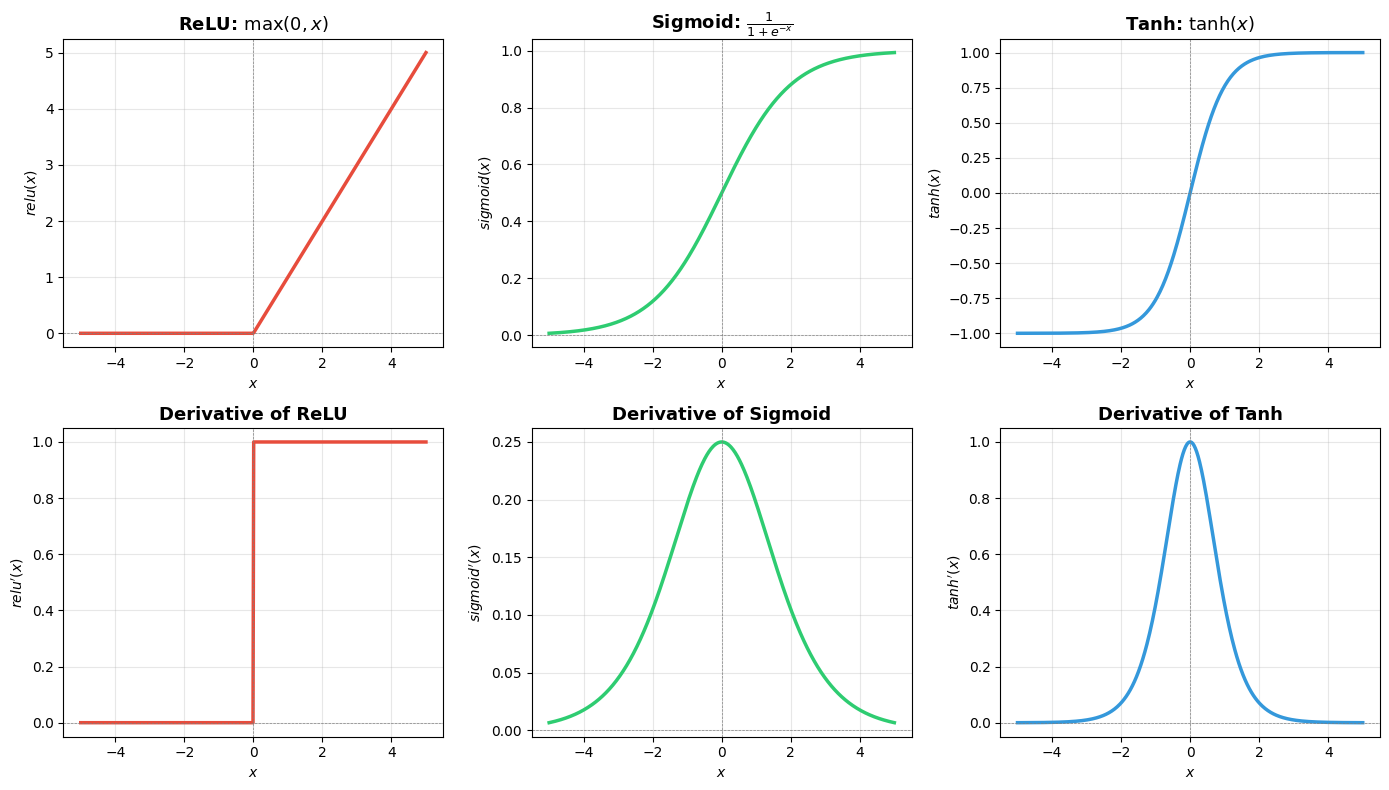

In [4]:
# Define activation functions and their derivatives
def relu(x):
    return jnp.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

def tanh(x):
    return jnp.tanh(x)

# Auto-differentiate to get derivatives
relu_grad = jax.vmap(jax.grad(lambda x: relu(x)))
sigmoid_grad = jax.vmap(jax.grad(lambda x: sigmoid(x)))
tanh_grad = jax.vmap(jax.grad(lambda x: tanh(x)))

x = jnp.linspace(-5, 5, 500)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

activations = [
    (relu, relu_grad, 'ReLU', r'$\max(0, x)$', '#e74c3c'),
    (sigmoid, sigmoid_grad, 'Sigmoid', r'$\frac{1}{1+e^{-x}}$', '#2ecc71'),
    (tanh, tanh_grad, 'Tanh', r'$\tanh(x)$', '#3498db'),
]

for i, (fn, grad_fn, name, formula, color) in enumerate(activations):
    # Function
    axes[0, i].plot(x, fn(x), color=color, linewidth=2.5)
    axes[0, i].axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    axes[0, i].axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
    axes[0, i].set_title(f'{name}: {formula}', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('$x$')
    axes[0, i].set_ylabel(f'${name.lower()}(x)$')
    axes[0, i].grid(True, alpha=0.3)
    
    # Derivative
    axes[1, i].plot(x, grad_fn(x), color=color, linewidth=2.5, linestyle='-')
    axes[1, i].axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    axes[1, i].axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
    axes[1, i].set_title(f"Derivative of {name}", fontsize=13, fontweight='bold')
    axes[1, i].set_xlabel('$x$')
    axes[1, i].set_ylabel(f"${name.lower()}'(x)$")
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Key Observations

- **ReLU**: Gradient is exactly 1 for $x > 0$, exactly 0 for $x < 0$. Simple, fast, and avoids vanishing gradients for positive inputs. The **default choice** for hidden layers.
- **Sigmoid**: Gradient peaks at 0.25 (at $x = 0$) and vanishes for large $|x|$. Historically popular, but causes **vanishing gradient** problems in deep networks. Now mainly used in output layers for binary classification.
- **Tanh**: Zero-centered (unlike sigmoid), gradient peaks at 1.0. Better than sigmoid for hidden layers, but still suffers from vanishing gradients at extremes.

### Why ReLU Won

The key advantage of ReLU: its gradient is either 0 or 1 — it never *shrinks* the gradient. When we chain many layers, sigmoid/tanh gradients multiply together and exponentially decay, while ReLU gradients stay intact.

---
## 3. Building an MLP from Scratch in JAX

Let's implement a complete MLP to learn a nonlinear function. We'll fit $f(x) = \sin(x)$ — a simple function that no linear model can capture.

### Step 1: Define the Model

An MLP with one hidden layer has parameters $\theta = \{\mathbf{W}_1, \mathbf{b}_1, \mathbf{W}_2, \mathbf{b}_2\}$:

$$\hat{y} = \mathbf{W}_2 \cdot \text{ReLU}(\mathbf{W}_1 x + \mathbf{b}_1) + \mathbf{b}_2$$

In [5]:
def init_mlp_params(key: jax.Array, layer_sizes: list[int]) -> list[dict]:
    """Initialize MLP parameters with small random weights.
    
    Args:
        key: JAX random key
        layer_sizes: [input_dim, hidden1, hidden2, ..., output_dim]
    
    Returns:
        List of {'W': weight_matrix, 'b': bias_vector} for each layer
    """
    params = []
    for i in range(len(layer_sizes) - 1):
        key, subkey = jr.split(key)
        n_in, n_out = layer_sizes[i], layer_sizes[i+1]
        # Xavier initialization (we'll discuss why later!)
        scale = jnp.sqrt(2.0 / (n_in + n_out))
        W = jr.normal(subkey, (n_in, n_out)) * scale
        b = jnp.zeros(n_out)
        params.append({'W': W, 'b': b})
    return params

def mlp_forward(params: list[dict], x: jax.Array) -> jax.Array:
    """Forward pass through MLP.
    
    Applies linear transformation + ReLU for all hidden layers,
    then a final linear transformation (no activation) for the output.
    """
    h = x
    # Hidden layers: linear + ReLU
    for layer in params[:-1]:
        h = h @ layer['W'] + layer['b']
        h = jax.nn.relu(h)
    # Output layer: linear only (no activation)
    h = h @ params[-1]['W'] + params[-1]['b']
    return h

# Test: create an MLP with architecture 1 → 32 → 32 → 1
key = jr.PRNGKey(0)
params = init_mlp_params(key, [1, 32, 32, 1])

print("MLP Architecture: 1 → 32 → 32 → 1")
for i, p in enumerate(params):
    print(f"  Layer {i+1}: W{list(p['W'].shape)}, b{list(p['b'].shape)}")
total_params = sum(p['W'].size + p['b'].size for p in params)
print(f"  Total parameters: {total_params}")

MLP Architecture: 1 → 32 → 32 → 1
  Layer 1: W[1, 32], b[32]
  Layer 2: W[32, 32], b[32]
  Layer 3: W[32, 1], b[1]
  Total parameters: 1153


### Step 2: Train the MLP

We define a **loss function** (MSE) and use `jax.grad` to compute gradients automatically. Then we train with gradient descent.

In [6]:
# Generate training data: y = sin(x) + noise
key = jr.PRNGKey(42)
k1, k2 = jr.split(key)

n_train = 200
x_train = jr.uniform(k1, (n_train, 1), minval=-2*jnp.pi, maxval=2*jnp.pi)
y_train = jnp.sin(x_train) + 0.1 * jr.normal(k2, (n_train, 1))

# Loss function: Mean Squared Error
def mse_loss(params, x, y):
    y_pred = mlp_forward(params, x)
    return jnp.mean((y_pred - y) ** 2)

# Training loop using optax
@jax.jit
def train_step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(mse_loss)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Initialize
key = jr.PRNGKey(0)
params = init_mlp_params(key, [1, 64, 64, 1])
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)

# Train
n_epochs = 2000
losses = []
for epoch in range(n_epochs):
    params, opt_state, loss = train_step(params, opt_state, x_train, y_train)
    losses.append(float(loss))
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss:.6f}")

Epoch  500 | Loss: 0.043190
Epoch 1000 | Loss: 0.007893
Epoch 1500 | Loss: 0.007522
Epoch 2000 | Loss: 0.007383


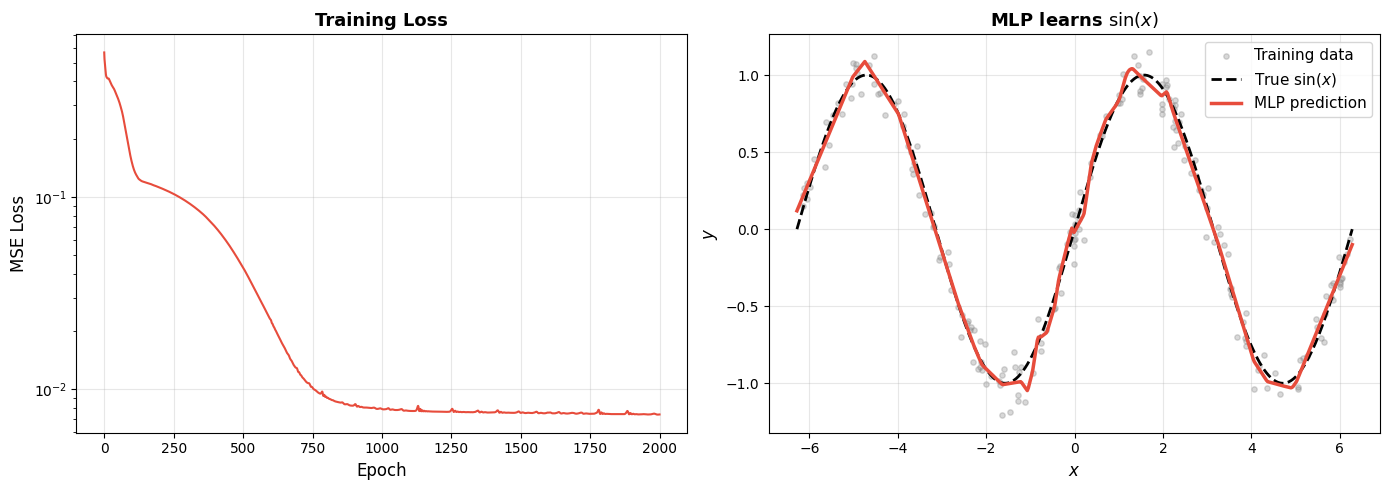

In [7]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Training loss
axes[0].semilogy(losses, color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: Function fit
x_test = jnp.linspace(-2*jnp.pi, 2*jnp.pi, 500).reshape(-1, 1)
y_pred = mlp_forward(params, x_test)

axes[1].scatter(x_train, y_train, alpha=0.3, s=15, color='gray', label='Training data')
axes[1].plot(x_test, jnp.sin(x_test), 'k--', linewidth=2, label=r'True $\sin(x)$')
axes[1].plot(x_test, y_pred, color='#e74c3c', linewidth=2.5, label='MLP prediction')
axes[1].set_xlabel('$x$', fontsize=12)
axes[1].set_ylabel('$y$', fontsize=12)
axes[1].set_title('MLP learns $\\sin(x)$', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Numerical Stability and Weight Initialization

*This section follows [d2l.ai §5.4](https://d2l.ai/chapter_multilayer-perceptrons/numerical-stability-and-init.html). Xavier initialization is from [Glorot & Bengio (2010)](http://proceedings.mlr.press/v9/glorot10a.html).*

### The Problem: Vanishing and Exploding Gradients

In a deep network with $L$ layers, the gradient of the loss w.r.t. early-layer weights involves a **product of many matrices**:

$$\frac{\partial L}{\partial \mathbf{W}^{(1)}} \propto \prod_{l=2}^{L} \mathbf{M}^{(l)}$$

where $\mathbf{M}^{(l)}$ depends on the weights and activation derivatives at layer $l$.

- If each $\mathbf{M}^{(l)}$ has eigenvalues $< 1$: gradients **vanish** exponentially $\rightarrow$ early layers don't learn
- If each $\mathbf{M}^{(l)}$ has eigenvalues $> 1$: gradients **explode** exponentially $\rightarrow$ training diverges

> **Physics analogy**: This is like a transfer matrix problem. If you multiply many matrices with eigenvalues $\neq 1$, the result either blows up or decays exponentially — familiar from tight-binding models or optical multilayers.

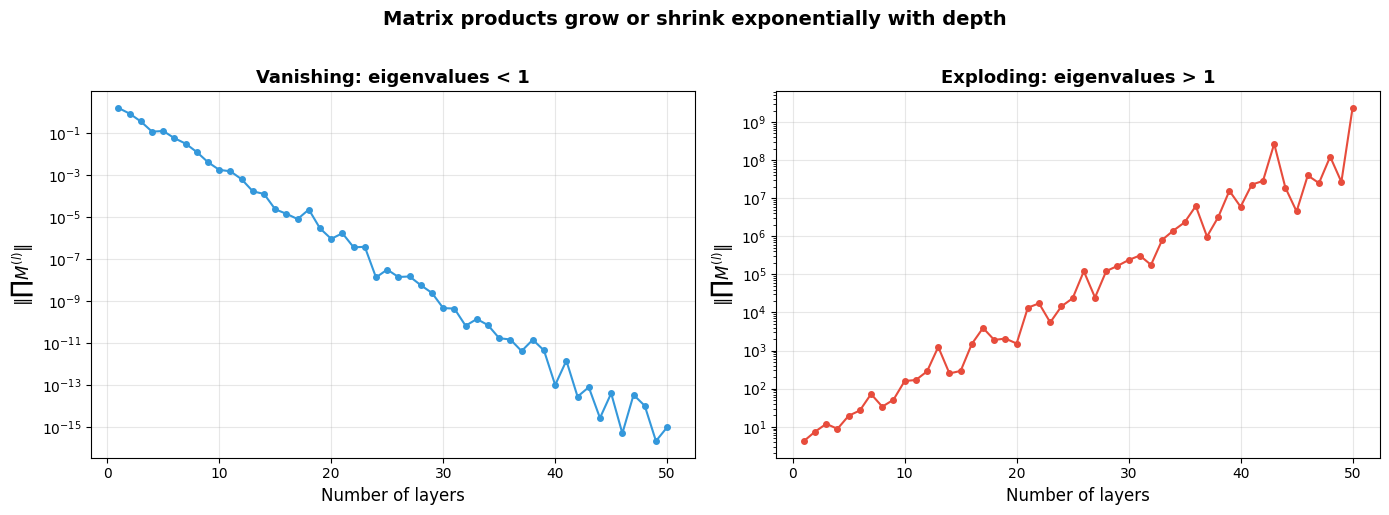

In [8]:
# Demonstration: multiplying many random matrices
key = jr.PRNGKey(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (scale, title, color) in zip(axes, [
    (0.5, 'Vanishing: eigenvalues < 1', '#3498db'),
    (1.5, 'Exploding: eigenvalues > 1', '#e74c3c'),
]):
    norms = []
    n = 10  # matrix size
    for n_layers in range(1, 51):
        key, subkey = jr.split(key)
        # Multiply n_layers random matrices
        result = jnp.eye(n)
        for _ in range(n_layers):
            key, subkey = jr.split(key)
            M = jr.normal(subkey, (n, n)) * scale / jnp.sqrt(n)
            result = result @ M
        norms.append(float(jnp.linalg.norm(result)))
    
    ax.semilogy(range(1, 51), norms, 'o-', color=color, markersize=4, linewidth=1.5)
    ax.set_xlabel('Number of layers', fontsize=12)
    ax.set_ylabel('$\\|\\prod M^{(l)}\\|$', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Matrix products grow or shrink exponentially with depth', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Xavier (Glorot) Initialization

*[Glorot & Bengio, "Understanding the difficulty of training deep feedforward neural networks," AISTATS 2010](http://proceedings.mlr.press/v9/glorot10a.html)*

The solution: choose initial weight variance so that **signal magnitude is preserved** across layers.

For a layer with $n_\text{in}$ inputs and $n_\text{out}$ outputs:
- Forward pass requires: $n_\text{in} \cdot \text{Var}(w) = 1$
- Backward pass requires: $n_\text{out} \cdot \text{Var}(w) = 1$

**Xavier compromise**: 

$$\text{Var}(w) = \frac{2}{n_\text{in} + n_\text{out}}$$

For a uniform distribution: $w \sim U\left(-\sqrt{\frac{6}{n_\text{in} + n_\text{out}}},\; \sqrt{\frac{6}{n_\text{in} + n_\text{out}}}\right)$

> **Note on ReLU**: The Xavier derivation assumes linear (or symmetric) activations. For ReLU, which zeroes out half of its inputs, [He et al. (2015)](https://arxiv.org/abs/1502.01852) showed that $\text{Var}(w) = 2/n_\text{in}$ ("Kaiming initialization") is more appropriate. In practice, both work reasonably well for moderate-depth networks, but He init is preferred when using ReLU.

### Symmetry Breaking

All weights must be initialized **randomly** (not to the same constant). If all weights are identical, every neuron computes the same function, receives the same gradient, and remains identical forever.

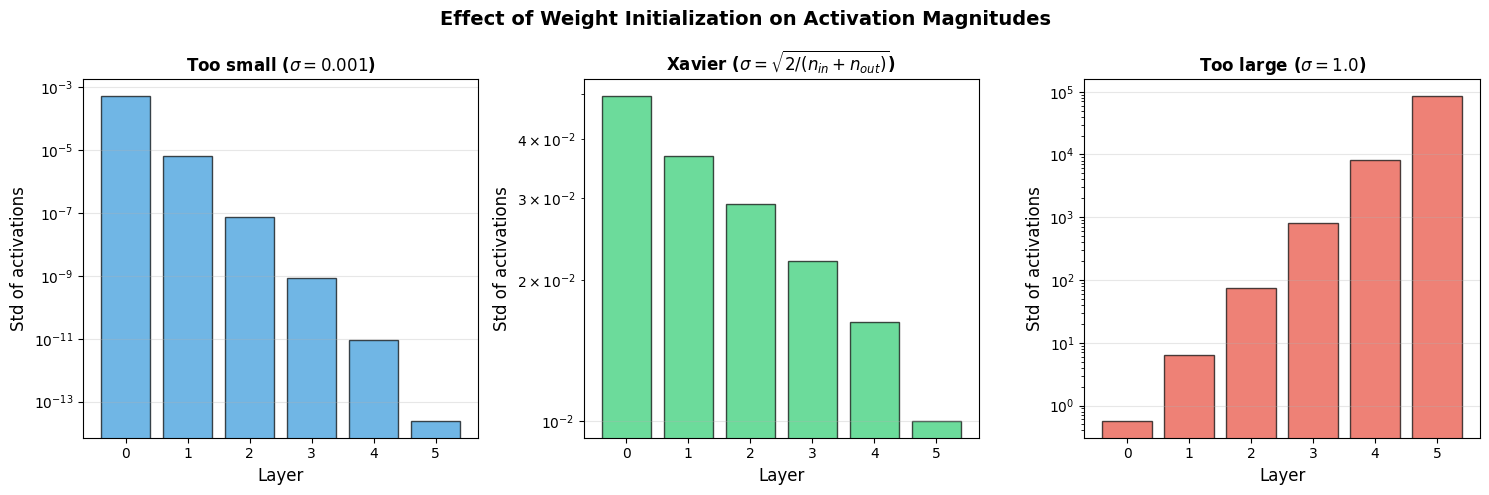

In [9]:
# Compare initialization strategies: track activation magnitudes through layers

def forward_track_activations(params, x):
    """Forward pass that records activation statistics at each layer."""
    h = x
    stats = []
    for layer in params[:-1]:
        h = h @ layer['W'] + layer['b']
        h = jax.nn.relu(h)
        stats.append({'mean': float(jnp.mean(jnp.abs(h))), 'std': float(jnp.std(h))})
    h = h @ params[-1]['W'] + params[-1]['b']
    stats.append({'mean': float(jnp.mean(jnp.abs(h))), 'std': float(jnp.std(h))})
    return stats

# Build a deep MLP: 1 → 256 → 256 → 256 → 256 → 256 → 1
layer_sizes = [1] + [256]*5 + [1]
key = jr.PRNGKey(42)

# Generate random input
x_test_init = jr.normal(jr.PRNGKey(99), (100, 1))

init_methods = {
    'Too small ($\\sigma = 0.001$)': 0.001,
    'Xavier ($\\sigma = \\sqrt{2/(n_{in}+n_{out})}$)': 'xavier',
    'Too large ($\\sigma = 1.0$)': 1.0,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, (name, scale), color in zip(axes, init_methods.items(), colors):
    params_test = []
    for i in range(len(layer_sizes) - 1):
        key, subkey = jr.split(key)
        n_in, n_out = layer_sizes[i], layer_sizes[i+1]
        if scale == 'xavier':
            s = jnp.sqrt(2.0 / (n_in + n_out))
        else:
            s = scale
        W = jr.normal(subkey, (n_in, n_out)) * s
        b = jnp.zeros(n_out)
        params_test.append({'W': W, 'b': b})
    
    stats = forward_track_activations(params_test, x_test_init)
    means = [s['mean'] for s in stats]
    stds = [s['std'] for s in stats]
    
    ax.bar(range(len(stats)), stds, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Layer', fontsize=12)
    ax.set_ylabel('Std of activations', fontsize=12)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Effect of Weight Initialization on Activation Magnitudes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Generalization: Underfitting and Overfitting

*This section follows [d2l.ai, "Generalization"](https://d2l.ai/chapter_multilayer-perceptrons/underfit-overfit.html). The polynomial fitting example is adapted from the same source.*

### Training Error vs. Generalization Error

- **Training error**: How well the model fits the data it was trained on
- **Generalization error** (test error): How well the model performs on **unseen** data

The goal of ML is to minimize generalization error, not training error.

### The Bias-Variance Tradeoff

| Regime | Training Error | Test Error | Problem |
|--------|---------------|------------|---------|
| **Underfitting** | High | High | Model too simple — can't capture the pattern |
| **Good fit** | Low | Low | Model complexity matches the data |
| **Overfitting** | Very low | High | Model memorizes noise instead of learning the pattern |

### Polynomial Fitting Example

We'll demonstrate with polynomial regression: fit $y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon$ using polynomials of different degrees.

/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/2992870716.py:27: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)


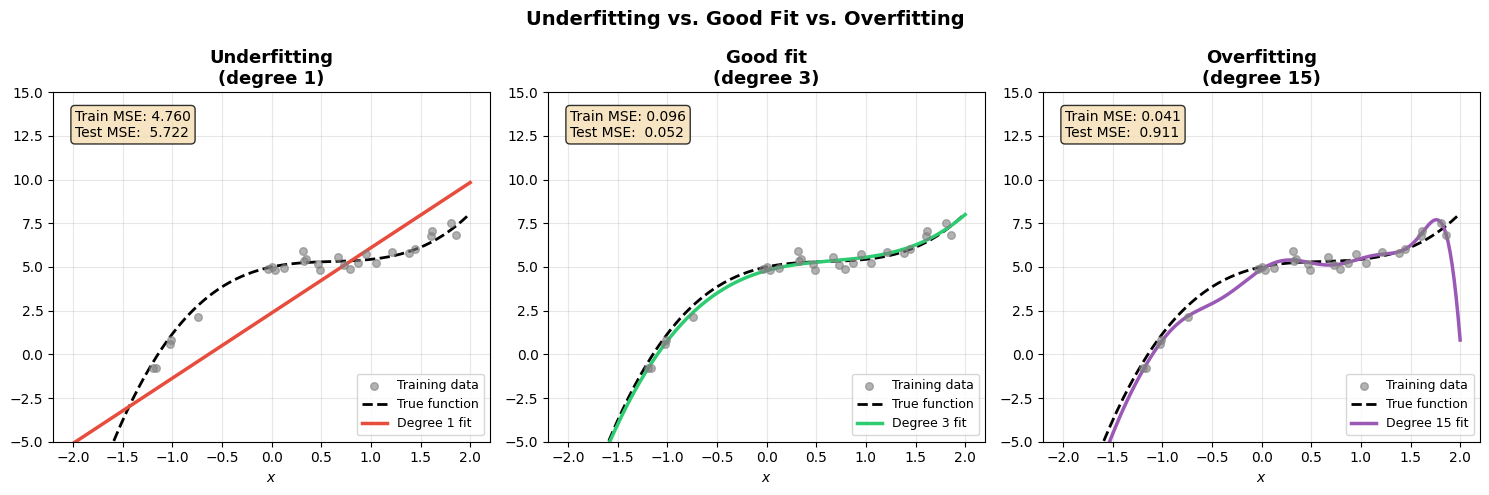

In [20]:
# Polynomial regression: underfitting, good fit, overfitting

# True function: y = 5 + 1.2x - 3.4x²/2! + 5.6x³/3!
def true_function(x):
    return 5 + 1.2*x - 3.4*x**2/2 + 5.6*x**3/6

# Generate data
key = jr.PRNGKey(42)
k1, k2, k3 = jr.split(key, 3)
n_train, n_test = 30, 200

x_tr = jnp.sort(jr.uniform(k1, (n_train,), minval=-2, maxval=2))
y_tr = true_function(x_tr) + jr.normal(k2, (n_train,)) * 0.5

x_te = jnp.linspace(-2, 2, n_test)
y_te_true = true_function(x_te)

# Fit polynomials of different degrees
degrees = [1, 3, 15]
titles = ['Underfitting\n(degree 1)', 'Good fit\n(degree 3)', 'Overfitting\n(degree 15)']
colors_poly = ['#e74c3c', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, deg, title, color in zip(axes, degrees, titles, colors_poly):
    # Fit polynomial using numpy (JAX doesn't have polyfit)
    coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
    poly = np.poly1d(coeffs)
    
    y_pred_train = poly(np.array(x_tr))
    y_pred_test = poly(np.array(x_te))
    
    train_err = np.mean((np.array(y_tr) - y_pred_train)**2)
    test_err = np.mean((np.array(y_te_true) - y_pred_test)**2)
    
    ax.scatter(x_tr, y_tr, color='gray', alpha=0.6, s=30, zorder=3, label='Training data')
    ax.plot(x_te, y_te_true, 'k--', linewidth=2, label='True function')
    ax.plot(x_te, y_pred_test, color=color, linewidth=2.5, label=f'Degree {deg} fit')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('$x$')
    ax.set_ylim(-5, 15)
    ax.text(0.05, 0.95, f'Train MSE: {train_err:.3f}\nTest MSE:  {test_err:.3f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Underfitting vs. Good Fit vs. Overfitting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/1324505124.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/1324505124.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/1324505124.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/1324505124.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_13440/1324505124.py:8: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
/var/folders/h3/b296rhks2f133q2fygydjy1m0000gn/T/ipykernel_1

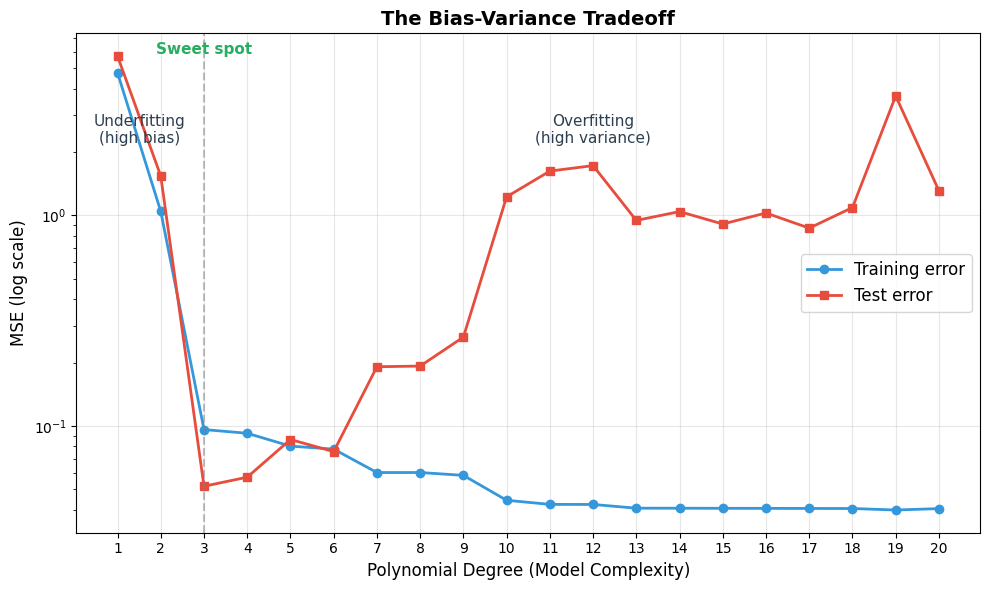

In [11]:
# The classic U-shaped curve: training vs test error as a function of model complexity

train_errors = []
test_errors = []
max_degree = 20

for deg in range(1, max_degree + 1):
    coeffs = np.polyfit(np.array(x_tr), np.array(y_tr), deg)
    poly = np.poly1d(coeffs)
    
    train_errors.append(np.mean((np.array(y_tr) - poly(np.array(x_tr)))**2))
    test_errors.append(np.mean((np.array(y_te_true) - poly(np.array(x_te)))**2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(range(1, max_degree+1), train_errors, 'o-', color='#3498db', 
            linewidth=2, markersize=6, label='Training error')
ax.semilogy(range(1, max_degree+1), test_errors, 's-', color='#e74c3c', 
            linewidth=2, markersize=6, label='Test error')

# Annotations
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
ax.text(1.5, ax.get_ylim()[1]*0.3, 'Underfitting\n(high bias)', ha='center', fontsize=11, color='#2c3e50')
ax.text(3, ax.get_ylim()[1]*0.8, 'Sweet spot', ha='center', fontsize=11, color='#27ae60', fontweight='bold')
ax.text(12, ax.get_ylim()[1]*0.3, 'Overfitting\n(high variance)', ha='center', fontsize=11, color='#2c3e50')

ax.set_xlabel('Polynomial Degree (Model Complexity)', fontsize=12)
ax.set_ylabel('MSE (log scale)', fontsize=12)
ax.set_title('The Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, max_degree+1))
plt.tight_layout()
plt.show()

### How to Combat Overfitting

| Strategy | Mechanism |
|----------|-----------|
| **More data** | Reduces variance; harder to memorize |
| **Simpler model** | Fewer parameters → less capacity to memorize |
| **Regularization** (weight decay) | Penalizes large weights: $J = L + \frac{\lambda}{2}\|\mathbf{W}\|^2$ |
| **Early stopping** | Stop training before the model memorizes noise |
| **Dropout** | Randomly disable neurons during training (next section) |
| **Data augmentation** | Artificially expand the dataset |


---
## 6. Dropout

*Dropout was introduced by [Srivastava, Hinton, Krizhevsky, Sutskever & Salakhutdinov, "Dropout: A Simple Way to Prevent Neural Networks from Overfitting," JMLR 2014](https://jmlr.org/papers/v15/srivastava14a.html). This section also follows [d2l.ai §5.6](https://d2l.ai/chapter_multilayer-perceptrons/dropout.html). The inverted dropout formulation (scaling by $1/(1-p)$ during training) is a widely adopted implementation convention (see, e.g., [Stanford CS231n](https://cs231n.github.io/neural-networks-2/#reg)).*

### Idea

Neural networks can **co-adapt**: certain neurons rely on specific other neurons, creating fragile internal representations. Dropout breaks co-adaptation by **randomly zeroing out** each hidden neuron with probability $p$ during training.

At test time, **all neurons are active** (no dropout). Since the training-time expected activation is $(1-p) \cdot h$, we need to compensate. Two equivalent approaches:

| | During Training | During Testing |
|---|---|---|
| **Standard dropout** | Zero out with prob $p$ | Multiply activations by $(1-p)$ |
| **Inverted dropout** ✓ | Zero out with prob $p$, then scale by $\frac{1}{1-p}$ | Use activations as-is |

We use **inverted dropout** (the modern standard) — it keeps the test-time forward pass unchanged.

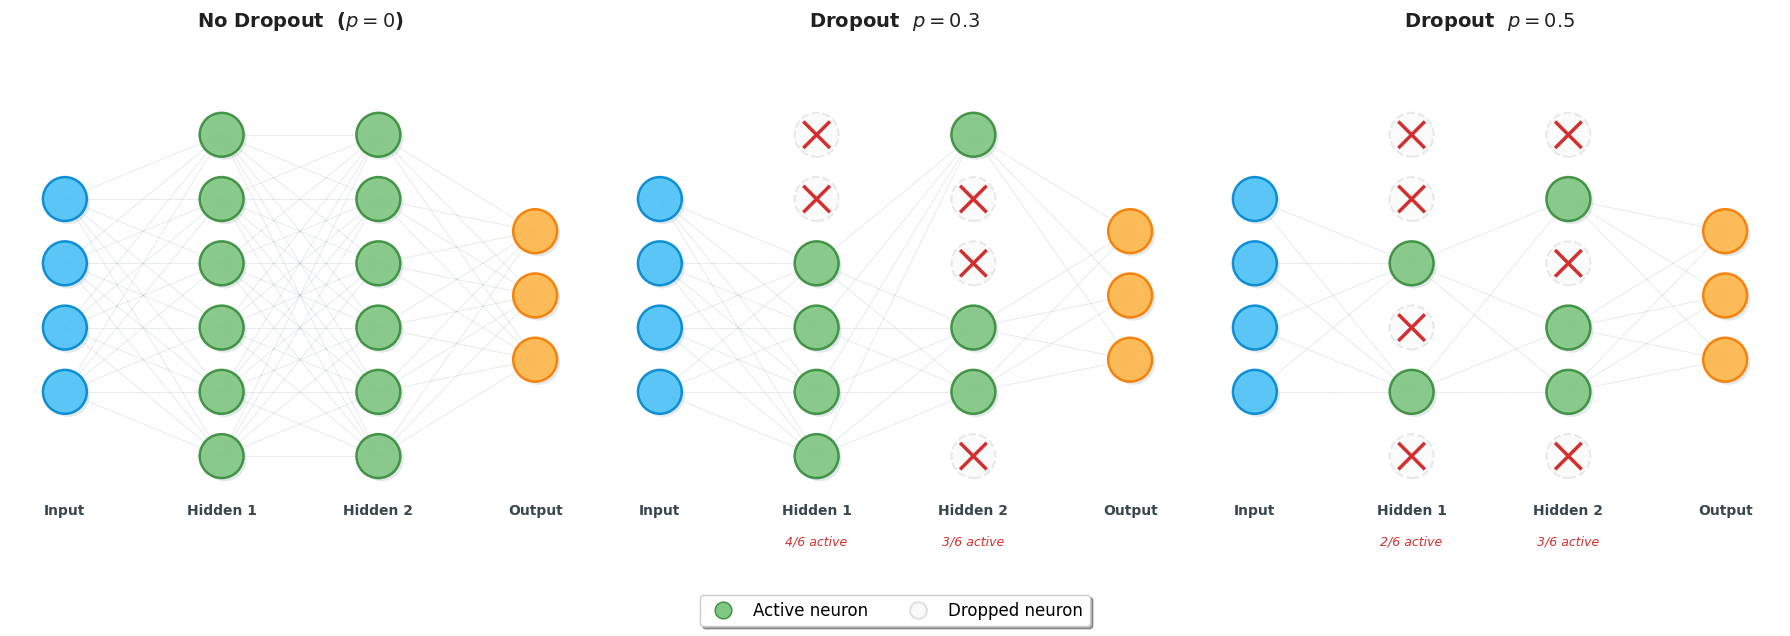

In [21]:
# ---------- Professional Dropout Visualization ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
layer_sizes_viz = [4, 6, 6, 3]
dropout_rates = [0.0, 0.3, 0.5]
titles_drop = ['No Dropout  ($p=0$)', 'Dropout  $p=0.3$', 'Dropout  $p=0.5$']

# Colors
C_drop = {
    'input':      '#4FC3F7',  'input_e':   '#0288D1',
    'hidden':     '#81C784',  'hidden_e':  '#388E3C',
    'output':     '#FFB74D',  'output_e':  '#F57C00',
    'dropped':    '#FAFAFA',  'dropped_e': '#E0E0E0',
    'cross':      '#D32F2F',
    'edge_on':    '#78909C',
    'edge_off':   '#E0E0E0',
    'shadow':     '#B0BEC5',
}

key = jr.PRNGKey(42)
h_sp, v_sp, r = 2.0, 0.82, 0.28

for ax, p_drop, title in zip(axes, dropout_rates, titles_drop):
    n_layers = len(layer_sizes_viz)
    max_n = max(layer_sizes_viz)

    # Decide which neurons to drop (hidden layers only)
    active = {}
    for i in range(n_layers):
        if i == 0 or i == n_layers - 1:
            active[i] = [True] * layer_sizes_viz[i]
        else:
            key, subkey = jr.split(key)
            mask = jr.bernoulli(subkey, 1 - p_drop, (layer_sizes_viz[i],))
            active[i] = [bool(m) for m in mask]

    # Positions
    pos = {}
    for i, size in enumerate(layer_sizes_viz):
        x = i * h_sp
        y_off = (max_n - size) * v_sp / 2
        for j in range(size):
            pos[(i, j)] = (x, y_off + j * v_sp)

    # --- Draw connections ---
    for i in range(n_layers - 1):
        for j in range(layer_sizes_viz[i]):
            for k in range(layer_sizes_viz[i + 1]):
                src_on = active[i][j]
                dst_on = active[i + 1][k]
                x1, y1 = pos[(i, j)]
                x2, y2 = pos[(i + 1, k)]
                if src_on and dst_on:
                    ax.plot([x1, x2], [y1, y2], color=C_drop['edge_on'],
                            alpha=0.18, linewidth=0.7, zorder=1)
                else:
                    ax.plot([x1, x2], [y1, y2], color=C_drop['edge_off'],
                            alpha=0.08, linewidth=0.4, zorder=1,
                            linestyle=(0, (4, 4)))

    # --- Draw neurons ---
    for i, size in enumerate(layer_sizes_viz):
        # Choose layer color
        if i == 0:
            fc, ec = C_drop['input'], C_drop['input_e']
        elif i == n_layers - 1:
            fc, ec = C_drop['output'], C_drop['output_e']
        else:
            fc, ec = C_drop['hidden'], C_drop['hidden_e']

        for j in range(size):
            x, y = pos[(i, j)]
            is_on = active[i][j]

            if is_on:
                # Shadow
                ax.add_patch(Circle((x + 0.04, y - 0.04), r,
                                     facecolor=C_drop['shadow'], edgecolor='none',
                                     alpha=0.35, zorder=2))
                # Active neuron
                ax.add_patch(Circle((x, y), r, facecolor=fc, edgecolor=ec,
                                     linewidth=1.8, alpha=0.92, zorder=4))
            else:
                # Dropped neuron — dashed border, empty
                ax.add_patch(Circle((x, y), r,
                                     facecolor=C_drop['dropped'],
                                     edgecolor=C_drop['dropped_e'],
                                     linewidth=1.5, linestyle='--',
                                     alpha=0.7, zorder=4))
                # Red cross
                d = r * 0.55
                ax.plot([x - d, x + d], [y - d, y + d],
                       color=C_drop['cross'], linewidth=2.5, zorder=5)
                ax.plot([x - d, x + d], [y + d, y - d],
                       color=C_drop['cross'], linewidth=2.5, zorder=5)

    # --- Layer bracket labels ---
    layer_names = ['Input', 'Hidden 1', 'Hidden 2', 'Output']
    for i, name in enumerate(layer_names):
        x = i * h_sp
        cnt = sum(active[i])
        total = layer_sizes_viz[i]
        sub = f'{cnt}/{total} active' if i in [1, 2] and p_drop > 0 else ''
        ax.text(x, -0.6, name, ha='center', va='top', fontsize=10,
               fontweight='bold', color='#37474F')
        if sub:
            ax.text(x, -1.0, sub, ha='center', va='top', fontsize=9,
                   color=C_drop['cross'], fontstyle='italic')

    # Title with badge-style background
    ax.set_title(title, fontsize=14, fontweight='bold', color='#212121', pad=15)

    # Clean axes
    ax.set_xlim(-0.7, (n_layers - 1) * h_sp + 0.7)
    ax.set_ylim(-1.5, max_n * v_sp + 0.3)
    ax.set_aspect('equal')
    ax.axis('off')

# Legend at the bottom
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_drop['hidden'],
           markeredgecolor=C_drop['hidden_e'], markersize=12, label='Active neuron'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=C_drop['dropped'],
           markeredgecolor=C_drop['dropped_e'], markersize=12,
           markeredgewidth=1.5, linestyle='--', label='Dropped neuron'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
          fontsize=12, frameon=True, fancybox=True, shadow=True,
          bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [13]:
# Implement dropout from scratch in JAX

def dropout(key, x, rate=0.5, training=True):
    """Apply dropout to activations.
    
    Args:
        key: JAX random key
        x: activations
        rate: probability of dropping a neuron (p)
        training: if False, no dropout is applied
    """
    if not training or rate == 0.0:
        return x
    mask = jr.bernoulli(key, 1 - rate, x.shape).astype(x.dtype)
    return mask * x / (1 - rate)

# Verify that E[dropout(x)] = x
key = jr.PRNGKey(0)
x_demo = jnp.ones((1000, 100))  # All ones

n_trials = 1000
outputs = []
for i in range(n_trials):
    key, subkey = jr.split(key)
    out = dropout(subkey, x_demo, rate=0.5, training=True)
    outputs.append(out.mean())

print(f"Input mean:                {x_demo.mean():.4f}")
print(f"Dropout output mean:       {jnp.mean(jnp.array(outputs)):.4f}")
print(f"Dropout output std:        {jnp.std(jnp.array(outputs)):.4f}")
print(f"\n→ Dropout preserves the expected value! (mean ≈ 1.0)")

Input mean:                1.0000
Dropout output mean:       1.0000
Dropout output std:        0.0031

→ Dropout preserves the expected value! (mean ≈ 1.0)


---
## 7. Putting It All Together: Regularization in Action

We now run three experiments that dramatically demonstrate why regularization matters. Each one is designed to make overfitting **visually obvious**.

### Experiment A: The Wiggly Curve (1D Regression)

We fit $y = \sin(2\pi x)$ with only **20 noisy samples** using a network with **4 layers × 256 units** (~200,000 parameters for 20 data points!). Without regularization, the network passes through every noisy point, creating wild oscillations.

> **Physics analogy**: This is like fitting noisy experimental data with too many free parameters.

In [22]:
# ========== Experiment A: The Wiggly Curve ==========

# 20 noisy samples from sin(2*pi*x)
key = jr.PRNGKey(42)
k1, k2 = jr.split(key)
n_pts = 20
x_data = jnp.sort(jr.uniform(k1, (n_pts, 1), minval=0.0, maxval=1.0), axis=0)
y_data = jnp.sin(2 * jnp.pi * x_data) + 0.3 * jr.normal(k2, (n_pts, 1))

x_dense = jnp.linspace(-0.05, 1.05, 500).reshape(-1, 1)
y_true = jnp.sin(2 * jnp.pi * x_dense)

# Massively overparameterized MLP: 1 → 256 → 256 → 256 → 256 → 1
ARCH = [1, 256, 256, 256, 256, 1]

def train_regressor(key, x, y, l2_lambda=0.0, dropout_rate=0.0,
                    n_epochs=8000, lr=1e-3):
    """Train an MLP for regression with optional regularization."""
    k1, k2 = jr.split(key)
    params = init_mlp_params(k1, ARCH)
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    def loss_fn(params, key):
        # Forward with dropout
        h = x
        for layer in params[:-1]:
            h = h @ layer['W'] + layer['b']
            h = jax.nn.relu(h)
            if dropout_rate > 0:
                key, subkey = jr.split(key)
                mask = jr.bernoulli(subkey, 1 - dropout_rate, h.shape).astype(h.dtype)
                h = mask * h / (1 - dropout_rate)
        h = h @ params[-1]['W'] + params[-1]['b']
        mse = jnp.mean((h - y) ** 2)
        if l2_lambda > 0:
            l2 = sum(jnp.sum(layer['W'] ** 2) for layer in params)
            return mse + 0.5 * l2_lambda * l2
        return mse
    
    @jax.jit
    def step(params, opt_state, key):
        loss, grads = jax.value_and_grad(loss_fn)(params, key)
        updates, new_opt = optimizer.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt, loss
    
    for epoch in range(n_epochs):
        k2, subkey = jr.split(k2)
        params, opt_state, loss = step(params, opt_state, subkey)
    
    return params, float(loss)

# Train 4 models
configs_reg = [
    ('No Regularization',          0.0,    0.0),
    ('Weight Decay ($\\lambda=10^{-3}$)', 1e-3,  0.0),
    ('Dropout ($p=0.5$)',           0.0,    0.5),
    ('Weight Decay + Dropout',     1e-3,   0.5),
]

key = jr.PRNGKey(123)
reg_results = {}
for name, l2, dr in configs_reg:
    key, subkey = jr.split(key)
    print(f"Training: {name}...")
    params_m, final_loss = train_regressor(subkey, x_data, y_data, l2, dr)
    reg_results[name] = params_m
    print(f"  Final loss: {final_loss:.6f}")

print("Done!")

Training: No Regularization...
  Final loss: 0.001533
Training: Weight Decay ($\lambda=10^{-3}$)...
  Final loss: 0.024494
Training: Dropout ($p=0.5$)...
  Final loss: 0.032048
Training: Weight Decay + Dropout...
  Final loss: 0.081355
Done!


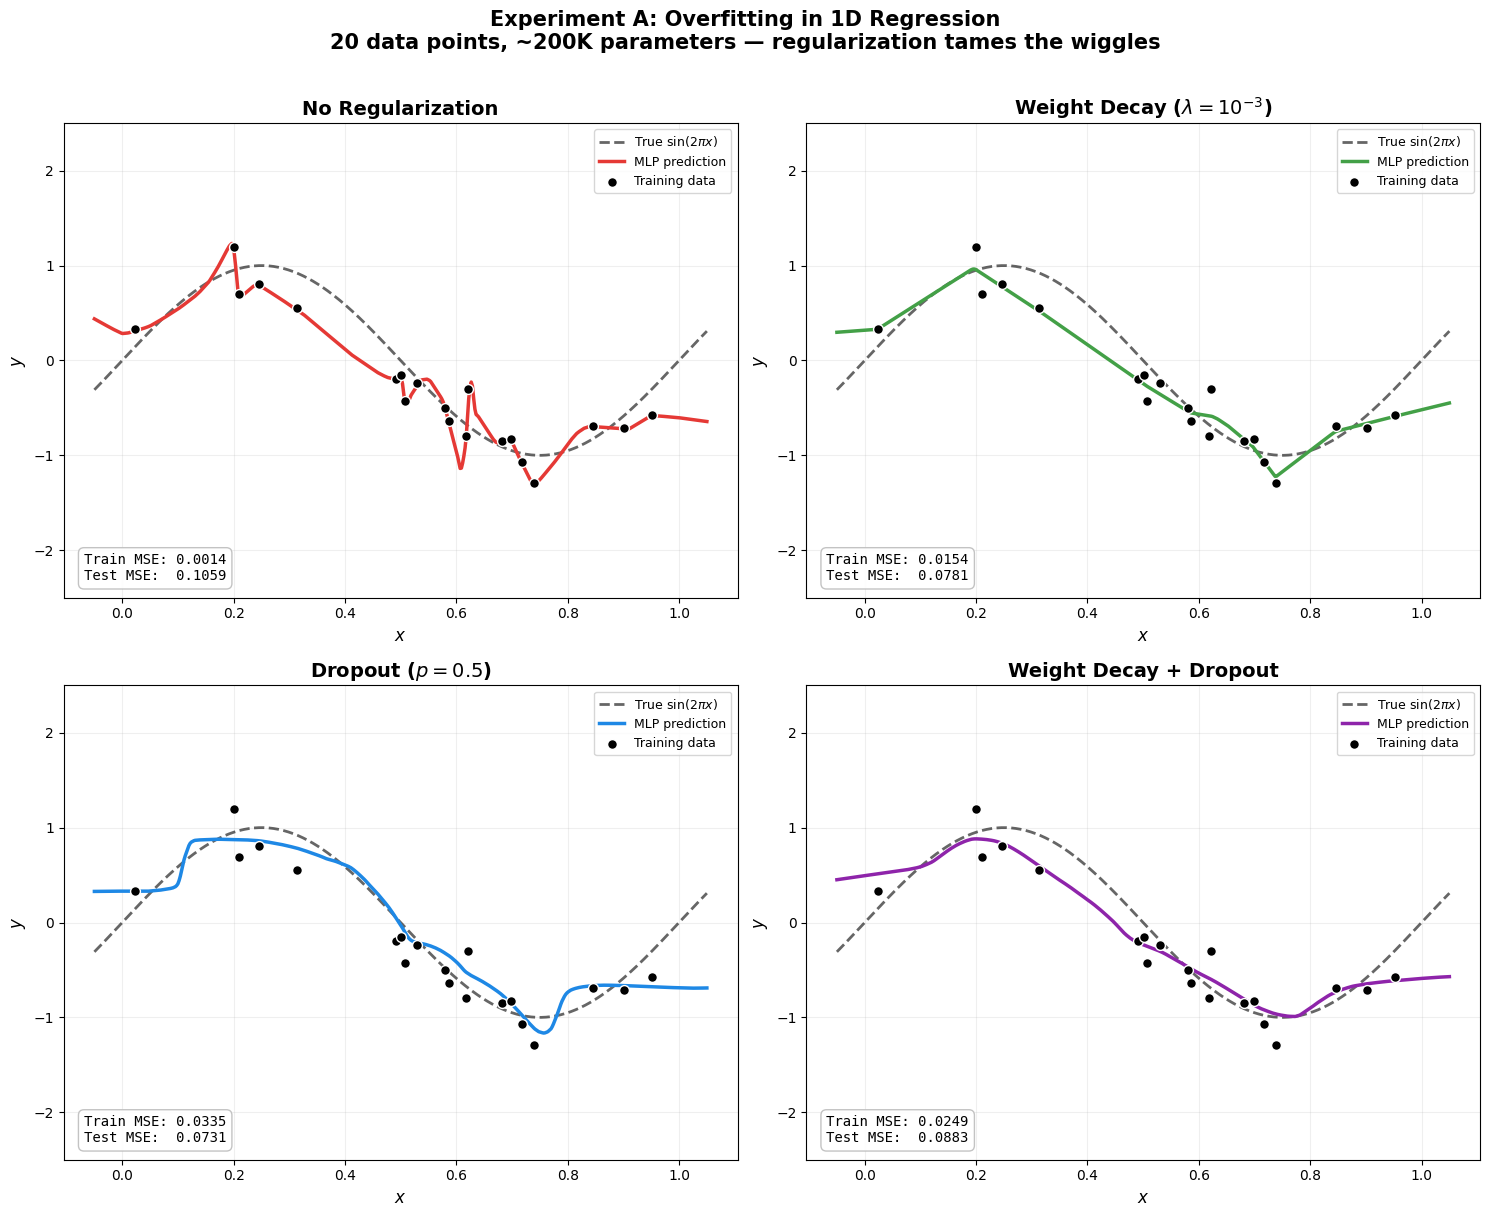

In [23]:
# ---------- Experiment A: Visualization ----------

fig, axes = plt.subplots(2, 2, figsize=(15, 12), facecolor='white')
colors_exp = ['#E53935', '#43A047', '#1E88E5', '#8E24AA']

for ax, (name, params_m), color in zip(axes.flat, reg_results.items(), colors_exp):
    # Predict on dense grid (no dropout at inference)
    y_pred = mlp_forward(params_m, x_dense)
    
    # Training MSE (on noisy data)
    y_pred_train = mlp_forward(params_m, x_data)
    train_mse = float(jnp.mean((y_pred_train - y_data) ** 2))
    # Test MSE (on true function)
    test_mse = float(jnp.mean((y_pred - y_true) ** 2))
    
    ax.plot(x_dense, y_true, 'k--', linewidth=2.0, alpha=0.6, label=r'True $\sin(2\pi x)$')
    ax.plot(x_dense, y_pred, color=color, linewidth=2.5, label='MLP prediction', zorder=3)
    ax.scatter(x_data, y_data, c='black', s=50, zorder=5, edgecolors='white',
              linewidth=1.0, label='Training data')
    
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.2)
    
    # MSE badge
    ax.text(0.03, 0.03,
           f'Train MSE: {train_mse:.4f}\nTest MSE:  {test_mse:.4f}',
           transform=ax.transAxes, fontsize=10, va='bottom',
           fontfamily='monospace',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                    edgecolor='#BDBDBD', alpha=0.9))

plt.suptitle('Experiment A: Overfitting in 1D Regression\n'
             '20 data points, ~200K parameters — regularization tames the wiggles',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Experiment B: Decision Boundaries with Noisy Labels

*The two-moons dataset is a standard benchmark from [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html); see also the [scikit-learn "Varying Regularization in MLP" example](https://scikit-learn.org/stable/auto_examples/neural_networks/plot_mlp_alpha.html). The idea of training on corrupted labels to study memorization is from [Zhang, S. Bengio, Hardt, Recht & Vinyals, "Understanding deep learning requires rethinking generalization," ICLR 2017](https://arxiv.org/abs/1611.03530).*

Now we make the classification problem harder: take the Two-Moons dataset and **randomly flip 15% of labels**. The network must decide: should it trust noisy labels (overfit) or find the smooth underlying boundary (generalize)?

Without regularization, the decision boundary develops bizarre **fingers and islands** to correctly classify every mislabeled point. With dropout, the boundary remains smooth.

Training samples: 150, with 22 noisy labels (15%)
Test samples: 500 (clean labels)


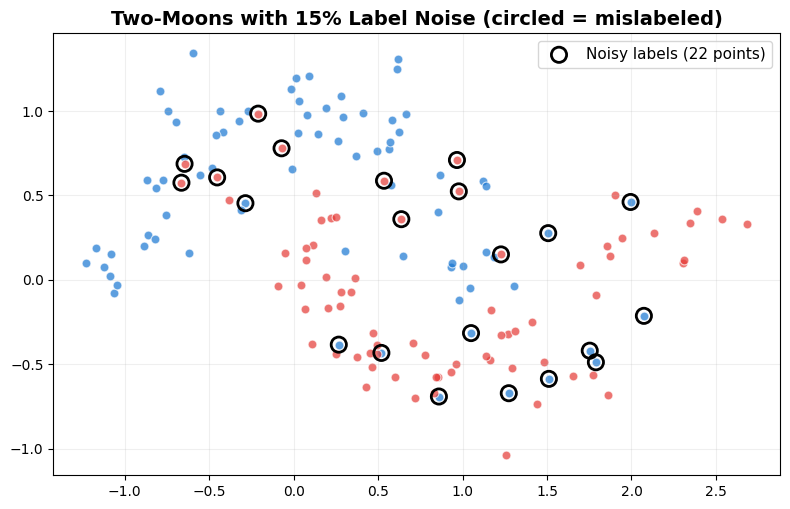

In [16]:
# ========== Experiment B: Noisy-Label Two-Moons ==========

def make_moons(key, n_samples=200, noise=0.20):
    """Generate two interleaving half-circles."""
    k1, k2 = jr.split(key)
    n_each = n_samples // 2
    theta1 = jnp.linspace(0, jnp.pi, n_each)
    x1 = jnp.stack([jnp.cos(theta1), jnp.sin(theta1)], axis=1)
    theta2 = jnp.linspace(0, jnp.pi, n_samples - n_each)
    x2 = jnp.stack([1 - jnp.cos(theta2), 1 - jnp.sin(theta2) - 0.5], axis=1)
    X = jnp.concatenate([x1, x2]) + noise * jr.normal(k1, (n_samples, 2))
    y = jnp.concatenate([jnp.zeros(n_each), jnp.ones(n_samples - n_each)])
    perm = jr.permutation(k2, n_samples)
    return X[perm], y[perm]

# Generate data with 15% label noise
key = jr.PRNGKey(77)
k1, k2, k3 = jr.split(key, 3)
X_train_m, y_train_m = make_moons(k1, n_samples=150, noise=0.20)
X_test_m, y_test_m = make_moons(k2, n_samples=500, noise=0.20)

# Flip 15% of training labels
n_flip = int(0.15 * len(y_train_m))
flip_idx = jr.choice(k3, len(y_train_m), (n_flip,), replace=False)
y_train_noisy = y_train_m.at[flip_idx].set(1 - y_train_m[flip_idx])

print(f"Training samples: {len(y_train_m)}, with {n_flip} noisy labels ({n_flip/len(y_train_m):.0%})")
print(f"Test samples: {len(y_test_m)} (clean labels)")

# Show which points are mislabeled
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
for label, color in [(0, '#1976D2'), (1, '#E53935')]:
    mask = y_train_noisy == label
    ax.scatter(X_train_m[mask, 0], X_train_m[mask, 1], c=color, s=40,
              edgecolors='white', linewidth=0.8, alpha=0.7)
# Highlight flipped points
ax.scatter(X_train_m[flip_idx, 0], X_train_m[flip_idx, 1], 
          facecolors='none', edgecolors='black', s=120, linewidth=2.0, 
          label=f'Noisy labels ({n_flip} points)', zorder=5)
ax.set_title('Two-Moons with 15% Label Noise (circled = mislabeled)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [17]:
# ---------- Train classifiers on noisy-label moons ----------

def mlp_classify(params, x, key, dropout_rate=0.0, training=True):
    """Forward pass for binary classification (returns logit)."""
    h = x
    for layer in params[:-1]:
        h = h @ layer['W'] + layer['b']
        h = jax.nn.relu(h)
        if training and dropout_rate > 0:
            key, subkey = jr.split(key)
            mask = jr.bernoulli(subkey, 1 - dropout_rate, h.shape).astype(h.dtype)
            h = mask * h / (1 - dropout_rate)
    return (h @ params[-1]['W'] + params[-1]['b']).squeeze(-1)

def bce_loss(params, x, y, key, dropout_rate=0.0, l2_lambda=0.0, training=True):
    """Numerically stable binary cross-entropy + optional L2."""
    logits = mlp_classify(params, x, key, dropout_rate, training)
    loss = jnp.mean(jnp.maximum(logits, 0) - logits * y + jnp.log1p(jnp.exp(-jnp.abs(logits))))
    if l2_lambda > 0:
        l2 = sum(jnp.sum(layer['W'] ** 2) for layer in params)
        loss = loss + 0.5 * l2_lambda * l2
    return loss

def accuracy(params, x, y, key):
    logits = mlp_classify(params, x, key, 0.0, False)
    return jnp.mean((logits > 0).astype(jnp.float32) == y)

def train_classifier(key, X, y, X_te, y_te, l2_lambda=0.0, dropout_rate=0.0,
                     n_epochs=4000, lr=3e-3):
    k1, k2 = jr.split(key)
    # Wider network: 2 → 256 → 256 → 256 → 1
    params = init_mlp_params(k1, [2, 256, 256, 256, 1])
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    @jax.jit
    def step(params, opt_state, key):
        loss, grads = jax.value_and_grad(bce_loss)(
            params, X, y, key, dropout_rate, l2_lambda, True)
        updates, new_opt = optimizer.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt, loss
    
    train_losses, test_losses = [], []
    for epoch in range(n_epochs):
        k2, subkey = jr.split(k2)
        params, opt_state, loss = step(params, opt_state, subkey)
        if epoch % 40 == 0 or epoch == n_epochs - 1:
            train_losses.append(float(loss))
            te_loss = bce_loss(params, X_te, y_te, subkey, 0.0, 0.0, False)
            test_losses.append(float(te_loss))
    
    return params, train_losses, test_losses

# Train 4 models
configs_b = [
    ('No Regularization',   0.0,    0.0),
    ('Weight Decay Only',   5e-3,   0.0),
    ('Dropout Only ($p=0.5$)', 0.0, 0.5),
    ('Weight Decay + Dropout', 5e-3, 0.5),
]

key = jr.PRNGKey(0)
results_b = {}
for name, l2, dr in configs_b:
    key, subkey = jr.split(key)
    print(f"Training: {name}...")
    params_m, tr_l, te_l = train_classifier(
        subkey, X_train_m, y_train_noisy, X_test_m, y_test_m, l2, dr)
    tr_acc = float(accuracy(params_m, X_train_m, y_train_noisy, subkey))
    te_acc = float(accuracy(params_m, X_test_m, y_test_m, subkey))
    results_b[name] = {'params': params_m, 'train_loss': tr_l, 'test_loss': te_l,
                       'train_acc': tr_acc, 'test_acc': te_acc}
    print(f"  Train acc: {tr_acc:.1%}, Test acc: {te_acc:.1%}")

print("Done!")

Training: No Regularization...
  Train acc: 100.0%, Test acc: 81.6%
Training: Weight Decay Only...
  Train acc: 92.0%, Test acc: 89.4%
Training: Dropout Only ($p=0.5$)...
  Train acc: 93.3%, Test acc: 85.0%
Training: Weight Decay + Dropout...
  Train acc: 84.7%, Test acc: 95.6%
Done!


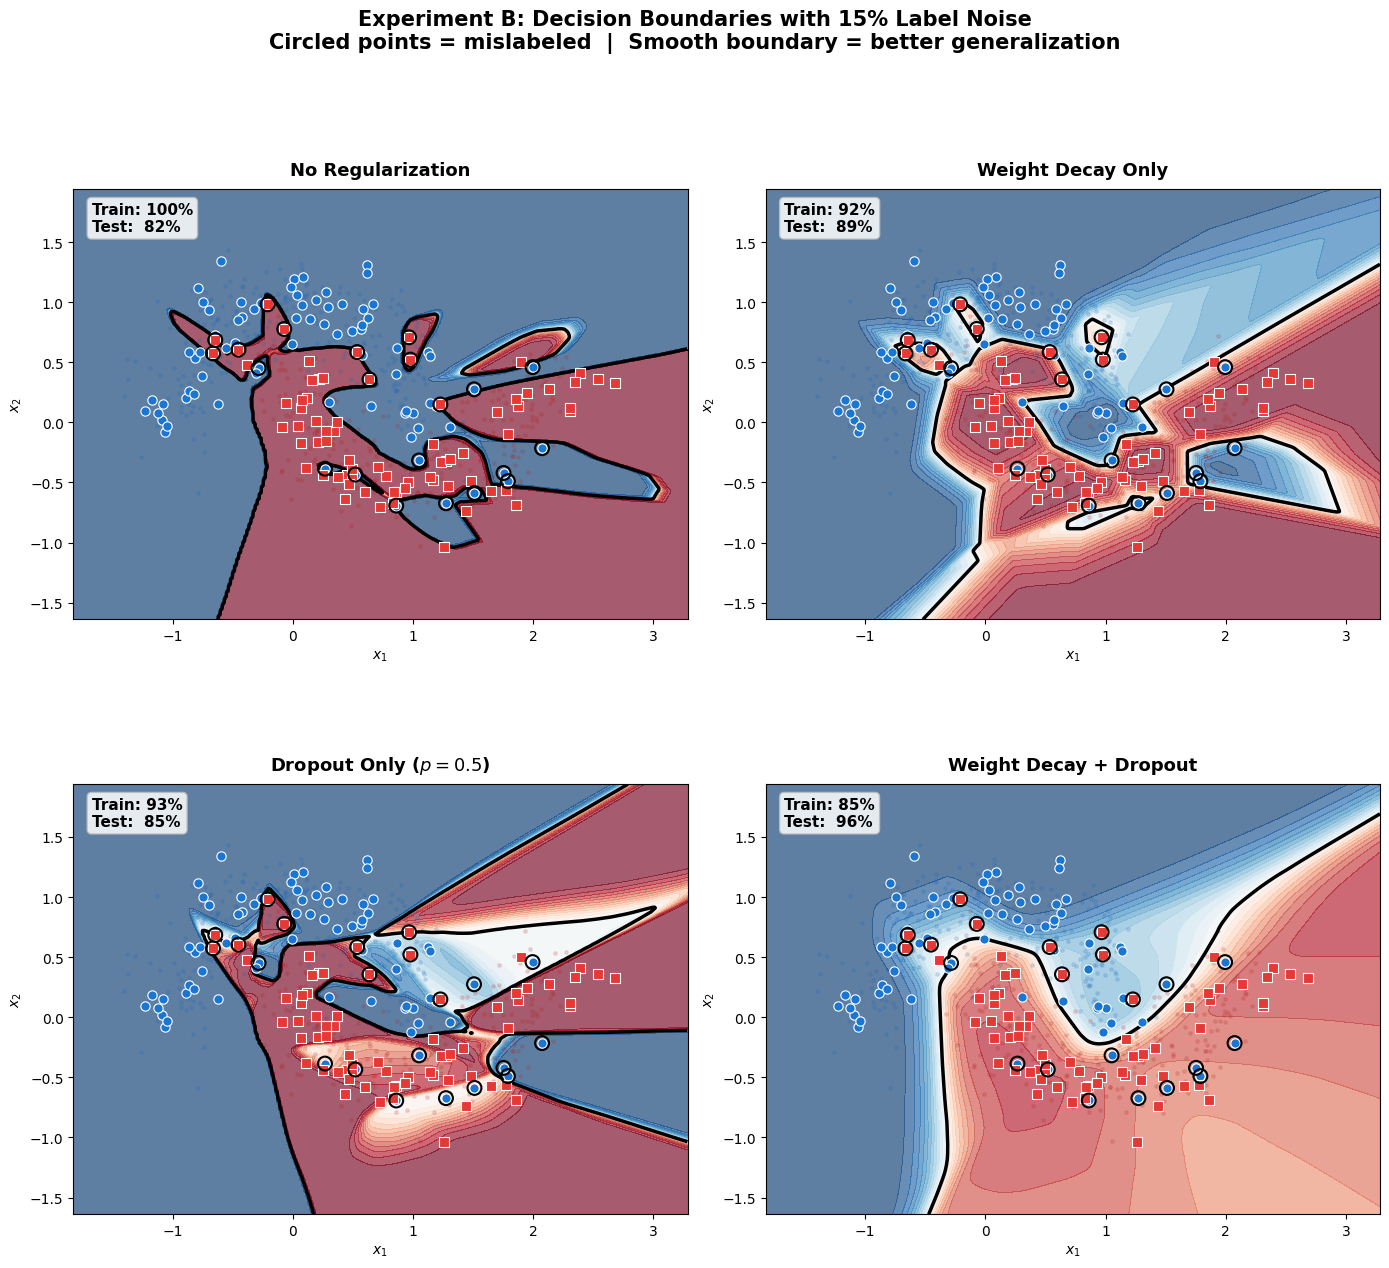

In [18]:
# ---------- Experiment B: Decision Boundary Comparison ----------

def plot_decision_boundary(ax, params, X_tr, y_tr, X_te, y_te, title,
                           flip_idx=None, resolution=300):
    """Plot decision boundary with confidence shading."""
    pad = 0.6
    x_min, x_max = float(X_tr[:, 0].min()) - pad, float(X_tr[:, 0].max()) + pad
    y_min, y_max = float(X_tr[:, 1].min()) - pad, float(X_tr[:, 1].max()) + pad
    xx, yy = jnp.meshgrid(jnp.linspace(x_min, x_max, resolution),
                           jnp.linspace(y_min, y_max, resolution))
    grid = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
    
    dummy_key = jr.PRNGKey(0)
    logits = mlp_classify(params, grid, dummy_key, 0.0, False)
    probs = jax.nn.sigmoid(logits).reshape(xx.shape)
    
    # Confidence heatmap
    ax.contourf(xx, yy, probs, levels=jnp.linspace(0, 1, 25),
               cmap='RdBu_r', alpha=0.65)
    # Decision boundary (thick black line)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2.5)
    
    # Test points (background)
    for label, color in [(0, '#1565C0'), (1, '#B71C1C')]:
        mask = y_te == label
        ax.scatter(X_te[mask, 0], X_te[mask, 1], c=color, s=6, alpha=0.15, zorder=1)
    
    # Train points
    for label, color, marker in [(0, '#1976D2', 'o'), (1, '#E53935', 's')]:
        mask = y_tr == label
        ax.scatter(X_tr[mask, 0], X_tr[mask, 1], c=color, s=45,
                  edgecolors='white', linewidth=0.8, marker=marker, zorder=3)
    
    # Highlight mislabeled points
    if flip_idx is not None:
        ax.scatter(X_tr[flip_idx, 0], X_tr[flip_idx, 1],
                  facecolors='none', edgecolors='black', s=100, linewidths=1.5, zorder=4)
    
    tr_acc = accuracy(params, X_tr, y_tr, dummy_key)
    te_acc = accuracy(params, X_te, y_te, dummy_key)
    ax.text(0.03, 0.97,
           f'Train: {tr_acc:.0%}\nTest:  {te_acc:.0%}',
           transform=ax.transAxes, fontsize=11, va='top', fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                    edgecolor='#BDBDBD'))
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

fig, axes = plt.subplots(2, 2, figsize=(14, 13), facecolor='white')

for ax, (name, res) in zip(axes.flat, results_b.items()):
    plot_decision_boundary(ax, res['params'], X_train_m, y_train_noisy,
                          X_test_m, y_test_m, name, flip_idx=flip_idx)

plt.suptitle('Experiment B: Decision Boundaries with 15% Label Noise\n'
             'Circled points = mislabeled  |  Smooth boundary = better generalization',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Experiment C: MC Dropout — Uncertainty Estimation

#### The Problem: Neural Networks Are Overconfident

A standard neural network gives you a **single prediction** — no error bars, no confidence interval. Ask it to predict in a region far from any training data, and it will give you a number with exactly the same confidence as in a data-rich region. However, **every measurement needs an uncertainty**.

#### The Insight (Gal & Ghahramani, 2016)

Dropout was originally designed as regularization. But Gal & Ghahramani showed that a network trained with dropout is mathematically equivalent to an **approximate Bayesian inference** over the network's weights.

The key idea:

> A network with dropout **implicitly represents an ensemble of exponentially many sub-networks** (each dropout mask selects a different sub-network). At test time, we can sample from this ensemble.

#### How MC Dropout Works — Step by Step

**During training** (standard dropout):
1. For each forward pass, randomly drop neurons with probability $p$
2. This is the same dropout we've been using — nothing new here

**During inference** (the new part — MC Dropout):
1. **Keep dropout ON** at test time (normally we turn it off!)
2. Run the **same input** through the network $T$ times, each time with a **different random dropout mask**
3. Each pass gives a slightly different prediction $\hat{y}_t$ because different neurons are dropped
4. The collection $\{\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_T\}$ forms a **distribution of predictions**

**Compute statistics from the distribution:**

$$\text{Predictive mean:} \quad \bar{y} = \frac{1}{T}\sum_{t=1}^{T} \hat{y}_t$$

$$\text{Predictive uncertainty:} \quad \sigma^2 = \frac{1}{T}\sum_{t=1}^{T} (\hat{y}_t - \bar{y})^2$$

#### Why Does This Give Uncertainty?

Think about it this way:
- In regions **with lots of training data**, the network has learned robust features. Dropping some neurons doesn't change the output much → **low variance** → high confidence
- In regions **with no training data**, the network hasn't learned anything reliable. Different sub-networks disagree wildly → **high variance** → low confidence

This is analogous to how in physics, the uncertainty on a fit parameter is larger when you have fewer data points constraining it.

#### Experiment Setup

We train on $\sin(2\pi x)$ with a deliberate **gap** in the data — no training points in $[0.35, 0.65]$. Then we compare:
- **Standard prediction**: single forward pass, no uncertainty
- **MC Dropout** ($T = 100$ samples): uncertainty bands from the ensemble

Training data: 24 points with a gap in [0.35, 0.65]


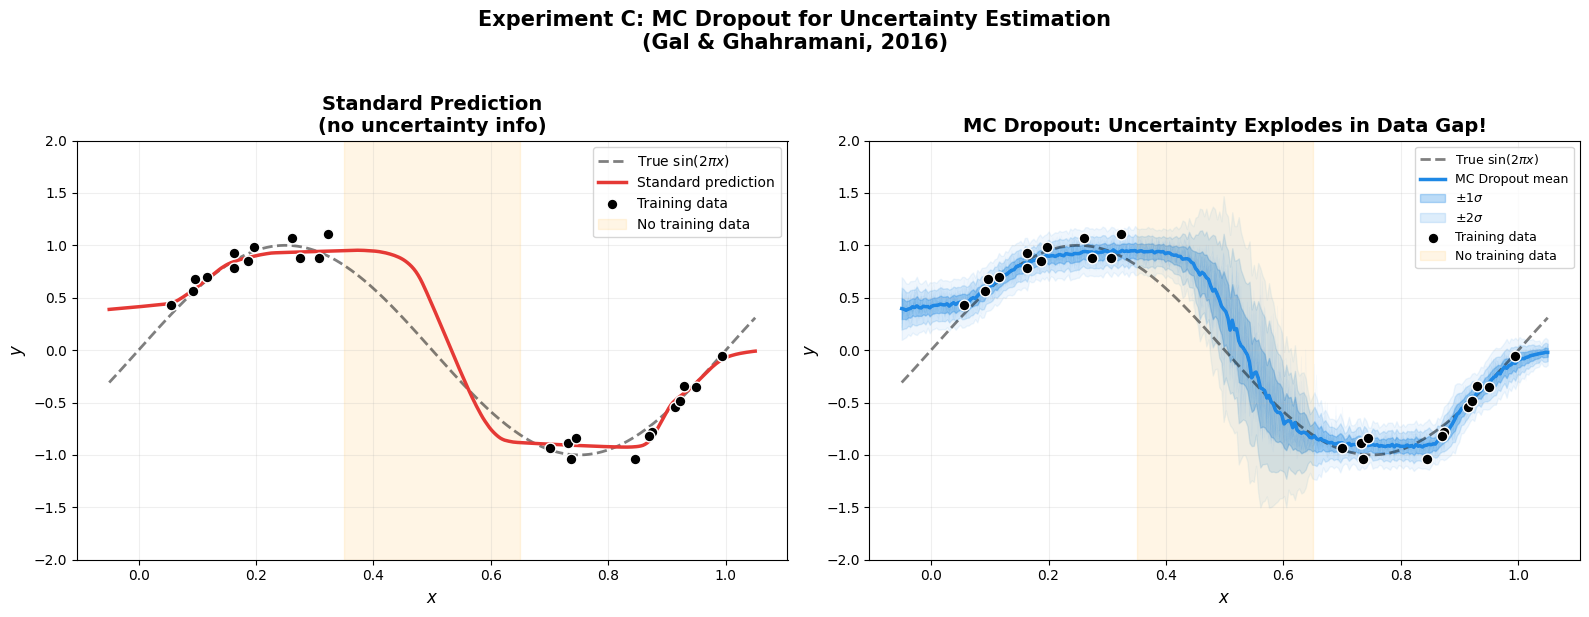

In [24]:
# ========== Experiment C: MC Dropout Uncertainty ==========

# Train a model with dropout on sin(x) — but with a GAP in the training data
key = jr.PRNGKey(99)
k1, k2 = jr.split(key)

# Data with a gap: train on [0, 0.35] ∪ [0.65, 1.0], no data in [0.35, 0.65]
n_left = 12
n_right = 12
x_left = jr.uniform(k1, (n_left, 1), minval=0.0, maxval=0.35)
x_right = jr.uniform(k2, (n_right, 1), minval=0.65, maxval=1.0)
x_gap = jnp.concatenate([x_left, x_right])
key, subkey = jr.split(key)
y_gap = jnp.sin(2 * jnp.pi * x_gap) + 0.1 * jr.normal(subkey, x_gap.shape)

print(f"Training data: {len(x_gap)} points with a gap in [0.35, 0.65]")

# Train with dropout
key, subkey = jr.split(key)
params_mc, _ = train_regressor(subkey, x_gap, y_gap, 
                                l2_lambda=1e-4, dropout_rate=0.3, 
                                n_epochs=5000, lr=1e-3)

# MC Dropout: 100 forward passes with dropout ENABLED at test time
x_mc = jnp.linspace(-0.05, 1.05, 300).reshape(-1, 1)
n_mc = 100

mc_predictions = []
key = jr.PRNGKey(42)
for i in range(n_mc):
    key, subkey = jr.split(key)
    # Forward with dropout ON (training=True equivalent)
    h = x_mc
    for layer in params_mc[:-1]:
        h = h @ layer['W'] + layer['b']
        h = jax.nn.relu(h)
        key, subkey = jr.split(key)
        mask = jr.bernoulli(subkey, 0.7, h.shape).astype(h.dtype)  # keep_prob = 1-0.3
        h = mask * h / 0.7
    h = h @ params_mc[-1]['W'] + params_mc[-1]['b']
    mc_predictions.append(h)

mc_preds = jnp.stack(mc_predictions, axis=0)  # (100, 300, 1)
mc_mean = mc_preds.mean(axis=0).squeeze()
mc_std = mc_preds.std(axis=0).squeeze()

# Standard prediction (no dropout)
y_standard = mlp_forward(params_mc, x_mc).squeeze()

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')
x_plot = x_mc.squeeze()
y_true_mc = jnp.sin(2 * jnp.pi * x_plot)

# Left: Standard prediction (no uncertainty)
axes[0].plot(x_plot, y_true_mc, 'k--', linewidth=2, alpha=0.5, label=r'True $\sin(2\pi x)$')
axes[0].plot(x_plot, y_standard, '#E53935', linewidth=2.5, label='Standard prediction')
axes[0].scatter(x_gap.squeeze(), y_gap.squeeze(), c='black', s=60,
               edgecolors='white', zorder=5, label='Training data')
axes[0].axvspan(0.35, 0.65, alpha=0.1, color='orange', label='No training data')
axes[0].set_title('Standard Prediction\n(no uncertainty info)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('$x$', fontsize=12)
axes[0].set_ylabel('$y$', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)
axes[0].set_ylim(-2, 2)

# Right: MC Dropout with uncertainty bands
axes[1].plot(x_plot, y_true_mc, 'k--', linewidth=2, alpha=0.5, label=r'True $\sin(2\pi x)$')
axes[1].plot(x_plot, mc_mean, '#1E88E5', linewidth=2.5, label='MC Dropout mean')

# Plot individual MC samples (faint)
for i in range(0, n_mc, 5):
    axes[1].plot(x_plot, mc_preds[i].squeeze(), '#1E88E5', alpha=0.04, linewidth=0.5)

# Confidence bands
for n_sigma, alpha in [(1, 0.3), (2, 0.15), (3, 0.07)]:
    axes[1].fill_between(x_plot, mc_mean - n_sigma * mc_std, mc_mean + n_sigma * mc_std,
                         alpha=alpha, color='#1E88E5',
                         label=f'$\\pm{n_sigma}\\sigma$' if n_sigma <= 2 else None)

axes[1].scatter(x_gap.squeeze(), y_gap.squeeze(), c='black', s=60,
               edgecolors='white', zorder=5, label='Training data')
axes[1].axvspan(0.35, 0.65, alpha=0.1, color='orange', label='No training data')
axes[1].set_title('MC Dropout: Uncertainty Explodes in Data Gap!', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('$x$', fontsize=12)
axes[1].set_ylabel('$y$', fontsize=12)
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.2)
axes[1].set_ylim(-2, 2)

plt.suptitle('Experiment C: MC Dropout for Uncertainty Estimation\n'
             '(Gal & Ghahramani, 2016)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Reading the MC Dropout Plot

**Left panel (Standard prediction)**:
- The red curve gives a single prediction everywhere
- In the orange gap region, the network **confidently predicts something** — but there's no data there to validate it!
- There's no way to tell which parts of the prediction are trustworthy and which are pure extrapolation

**Right panel (MC Dropout)**:
- The blue band shows the **spread** of 100 different predictions (each with a different dropout mask)
- Where there is training data (left and right), the band is **narrow** — all sub-networks agree
- In the gap where there is no data, the band **fans out dramatically** — the sub-networks disagree because they haven't learned anything consistent there
- This is exactly the behavior we want: **the model tells us where it doesn't know**

#### Standard Dropout vs. MC Dropout — Summary

| | Standard Dropout | MC Dropout |
|---|---|---|
| **Training** | Dropout ON (random masking) | Same — dropout ON |
| **Inference** | Dropout OFF (use all neurons) | Dropout ON (keep masking!) |
| **Output** | Single prediction | Distribution of predictions |
| **Uncertainty** | Not available | $\sigma = \text{std of predictions}$ |
| **Cost** | 1 forward pass | $T$ forward passes ($T \sim 30$–$100$) |



---
## Summary

| Topic | Key Takeaway |
|-------|-------------|
| **MLPs** | Stack linear layers with nonlinear activations to approximate any function |
| **Activation Functions** | ReLU is the default; its gradient never shrinks, avoiding vanishing gradients |
| **Initialization** | Xavier init preserves signal magnitude — too small → vanishing, too large → exploding |
| **Underfitting/Overfitting** | Too few parameters → underfitting; too many → overfitting the noise |
| **Weight Decay** | Penalizes large weights ($L + \frac{\lambda}{2}\|\mathbf{W}\|^2$), smoothing the learned function |
| **Dropout** | Randomly zeros activations during training, preventing neuron co-adaptation |
| **MC Dropout** | Enables uncertainty estimation by running dropout at test time |

### What We Saw in the Experiments

| Experiment | Without Regularization | With Regularization |
|-----------|----------------------|-------------------|
| **A: Wiggly Curve** | Wild oscillations through every noisy point | Smooth approximation of true $\sin(2\pi x)$ |
| **B: Noisy Labels** | Jagged boundary with fingers/islands around mislabeled points | Clean, smooth decision boundary |
| **C: MC Dropout** | Single prediction, no confidence info | Uncertainty bands that explode in data gaps |

### References

**Textbook & course material:**
- [Zhang, Lipton, Li & Smola, *Dive into Deep Learning*, Ch. 5](https://d2l.ai/chapter_multilayer-perceptrons/index.html) — primary reference for Sections 1–6

**Foundational papers:**
- Cybenko (1989), ["Approximation by superpositions of a sigmoidal function"](https://doi.org/10.1007/BF02551274) — Universal Approximation Theorem
- Glorot & Bengio (2010), ["Understanding the difficulty of training deep feedforward neural networks"](http://proceedings.mlr.press/v9/glorot10a.html) — Xavier initialization (§4)
- Nair & Hinton (2010), ["Rectified Linear Units Improve Restricted Boltzmann Machines"](https://www.cs.toronto.edu/~hinton/absps/reluICML.pdf) — ReLU activation (§2)
- Glorot, Bordes & Bengio (2011), ["Deep Sparse Rectifier Neural Networks"](http://proceedings.mlr.press/v15/glorot11a.html) — ReLU in deep feedforward networks
- He, Zhang, Ren & Sun (2015), ["Delving Deep into Rectifiers"](https://arxiv.org/abs/1502.01852) — Kaiming initialization for ReLU networks
- Srivastava et al. (2014), ["Dropout: A Simple Way to Prevent Neural Networks from Overfitting"](https://jmlr.org/papers/v15/srivastava14a.html) — Dropout (§6)
- Gal & Ghahramani (2016), ["Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning"](https://arxiv.org/abs/1506.02142) — MC Dropout (Experiment C)

**Experiment design references:**
- Bishop (1995), *Neural Networks for Pattern Recognition*, Ch. 1 — noisy sine-curve fitting (Experiment A)
- Zhang, S. Bengio, Hardt, Recht & Vinyals (2017), ["Understanding deep learning requires rethinking generalization"](https://arxiv.org/abs/1611.03530) — training on corrupted labels (Experiment B)
- MacKay (1992), ["A Practical Bayesian Framework for Backpropagation Networks"](https://doi.org/10.1162/neco.1992.4.3.415) — weight decay as Bayesian prior (§5)